# Text Analysis: Chunking Strategy Exploration

Reads the reniews text directly from the SQL database (not the CSV)
to replicate how a production embedding pipeline would access this
data. Explores text length distributions across `desc_1`, `desc_3`,
and `desc_2_clean` to inform whether to embed them as separate chunks
or combine them into one passage per review.

In [1]:
import pandas as pd
import sqlite3
from pathlib import Path

# Project paths — same structure as 02_database_setup.ipynb
cwd = Path.cwd()
PROJECT_ROOT = cwd.parents[0]
DATA_ROOT = PROJECT_ROOT / 'data'
SQL_DATA_ROOT = PROJECT_ROOT / 'db'

SQL_DB_PATH = SQL_DATA_ROOT / 'coffee_reviews.db'

In [5]:
conn= sqlite3.connect(SQL_DB_PATH)

query_text = """
            SELECT review_uid, desc_1, desc_2_clean, desc_3 
            FROM coffee_reviews_text
"""

text_df = pd.read_sql_query(query_text, conn)
conn.close()
print(f'Shape: {text_df.shape}')
text_df.info()
text_df.head()

Shape: (2280, 4)
<class 'pandas.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   review_uid    2280 non-null   str  
 1   desc_1        2280 non-null   str  
 2   desc_2_clean  2279 non-null   str  
 3   desc_3        2280 non-null   str  
dtypes: str(4)
memory usage: 71.4 KB


,review_uid,desc_1,desc_2_clean,desc_3
0,541f70da-4449-4acd-865d-38cbca91a597,"Evaluated as espresso. Sweet-toned, deeply ric...",An espresso blend comprised of coffees from Pa...,A radiant espresso blend that shines equally i...
1,48c30ff5-4757-4f70-823a-66578a7d53a5,"Evaluated as espresso. Sweetly tart, floral-to...",An espresso blend comprised of coffees from Af...,"A floral-driven straight shot, amplified with ..."
2,ab98d11a-575b-44e6-9826-0b841a1d5e11,"Crisply sweet, cocoa-toned. Lemon blossom, roa...",This coffee tied for the third-highest rating ...,"A gently spice-toned, floral- driven wet-proce..."
3,01442a89-853a-44db-b9d2-d7a239c7bc45,"Delicate, sweetly spice-toned. Pink peppercorn...",This coffee tied for the third-highest rating ...,Lavender-like flowers and hints of zesty pink ...
4,a22d7940-0505-43ac-95d4-79efd6e024df,"Deeply sweet, subtly pungent. Honey, pear, tan...",Southern Ethiopia coffees like this one are pr...,A deeply and generously lush cup saved from se...


## Step 2: Text Length Analysis

Compute word counts for each text field individually and combined,
then estimate token counts using the standard ~0.75 words-per-token
approximation (100 tokens ≈ 75 words), as a first-pass proxy before
committing to a specific embedding model's tokenizer.

In [6]:
TOKENS_PER_WORD_RATIO = 0.75  # ~100 tokens ≈ 75 words (OpenAI's rule of thumb)

# Word counts per field (simple whitespace split as a quick proxy)
for col in ['desc_1', 'desc_3', 'desc_2_clean']:
    text_df[f'{col}_word_count'] = text_df[col].fillna('').str.split().str.len()

# Combined text: all three fields concatenated into one passage
text_df['combined_text'] = (
    text_df['desc_1'].fillna('') + ' ' +
    text_df['desc_3'].fillna('') + ' ' +
    text_df['desc_2_clean'].fillna('')
)
text_df['combined_word_count'] = text_df['combined_text'].str.split().str.len()

# Estimated token counts: words / 0.75
for col in ['desc_1', 'desc_3', 'desc_2_clean', 'combined']:
    word_col = f'{col}_word_count'
    token_col = f'{col}_token_estimate'
    text_df[token_col] = (text_df[word_col] / TOKENS_PER_WORD_RATIO).round().astype(int)

text_df.filter(like='word_count').describe()

,desc_1_word_count,desc_3_word_count,desc_2_clean_word_count,combined_word_count
count,2280.000000,2280.000000,2280.000000,2280.000000
mean,38.989035,17.058333,70.029825,126.077193
std,8.160004,5.727973,28.660149,32.147207
min,7.000000,4.000000,0.000000,35.000000
25%,34.000000,13.000000,50.000000,104.000000
50%,38.000000,16.000000,65.500000,120.000000
75%,43.000000,20.000000,85.000000,143.000000
max,75.000000,48.000000,211.000000,283.000000


In [7]:
'''
Token estimates, plus tail percentiles (90th/95th/99th) — these matter more
than mean/max for chunking decisions, since they show how many reviews
would actually risk hitting a context limit
'''
token_cols = text_df.filter(like='token_estimate')
print(token_cols.describe())
print('\nUpper percentiles:')
print(token_cols.quantile([0.90, 0.95, 0.99]))

       desc_1_token_estimate  desc_3_token_estimate  \
count            2280.000000            2280.000000   
mean               51.984649              22.750439   
std                10.886999               7.644441   
min                 9.000000               5.000000   
25%                45.000000              17.000000   
50%                51.000000              21.000000   
75%                57.000000              27.000000   
max               100.000000              64.000000   

       desc_2_clean_token_estimate  combined_token_estimate  
count                  2280.000000              2280.000000  
mean                     93.363596               168.103509  
std                      38.214388                42.860804  
min                       0.000000                47.000000  
25%                      67.000000               139.000000  
50%                      87.500000               160.000000  
75%                     113.000000               191.000000  
max     

## Step 3: Visualize Length Distributions

Histograms make it easy to spot skew, outliers, and whether the three
fields are roughly balanced in length or one dominates.

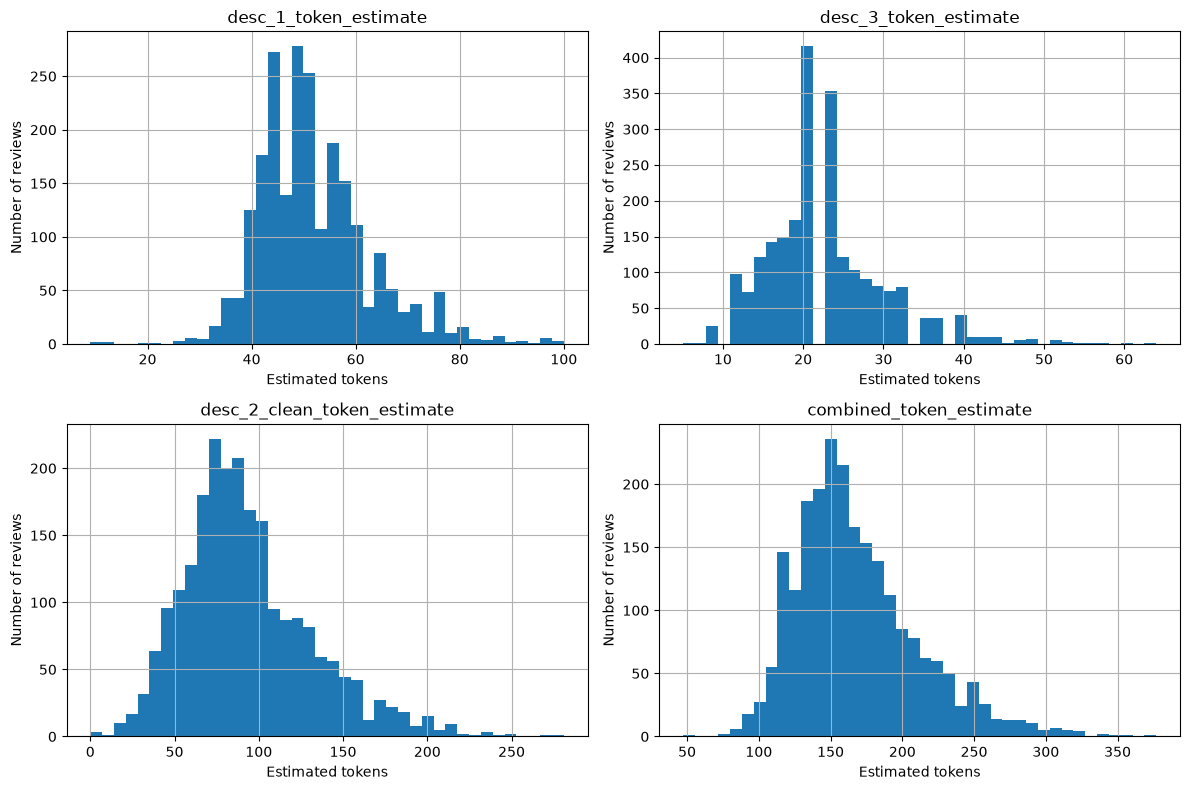

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols_to_plot = ['desc_1_token_estimate', 'desc_3_token_estimate',
                 'desc_2_clean_token_estimate', 'combined_token_estimate']

for ax, col in zip(axes.flat, cols_to_plot):
    text_df[col].hist(bins=40, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Estimated tokens')
    ax.set_ylabel('Number of reviews')

plt.tight_layout()
plt.show()

## Initial Chunking Strategy: Combine All Three Descriptions

Based on the text length analysis above, the initial chunking strategy for this
project combines `desc_1`, `desc_3`, and `desc_2_clean` into a single
passage per review for embedding, rather than treating each field as
its own chunk.

**Reasoning:**

- **Context limit is not a constraint.** The combined text tops out
  around 350 tokens - comfortably within the context window of any
  production-scale embedding model, this has no meaningful risk of
  truncation.
- **Field lengths are imbalanced.** `desc_2_clean` carries most of the
  text regarding the company and other attributes not necessarily related
  to tasting notes, while `desc_3` is comparatively sparse (max ~60 tokens).
  Embedding `desc_3` on its own would produce short, low-signal embeddings -
  vectors that might lack enough distinguishing content to be reliably discriminative
  at retrieval time.

Another chuncking strategy worth trying would be combining "desc_1' and "desc_3" and leaving 
"desc_2_clean" by itself since 1 and 3 arefocused on tasting notes and the overall take away and
2 focuses on toher attributes such as sourcing, organic, origin, bussiness details, etc.